In [1]:
import os
import glob
import gc
import random

import numpy as np
import pandas as pd

import torch

import matplotlib.pyplot as plt
import seaborn as sns

import scanpy as sc
import scvi

import pegasus as pg
from pegasusio import UnimodalData

%matplotlib inline

sc.settings.n_jobs = 25

random.seed(0)
np.random.seed(0)
sc.settings.seed = 0

torch.set_float32_matmul_precision("high")

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/flax/struct.py:132: FutureWarning: jax.tree_util.register_keypaths is deprecated, and will be removed in a future release. Please use `register_pytree_with_keys()` instead.
  jax.tree_util.register_keypaths(data_clz, keypaths)


In [2]:
## Load Dataset ##

# Ref - Braun #
braun_adata = sc.read_h5ad('/home/deepak/datasets/developing_neocortex/Braun_Linnarsson_2023/human_dev_clustered.h5ad')

# Ref - Query #
adata = sc.read_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/integrated_adata.h5ad')

In [3]:
## Create Subregion_Class ##

braun_adata.obs['Subregion_Class'] = braun_adata.obs['Subregion'].astype('str') + '_' + braun_adata.obs['CellClass'].astype('str')

In [4]:
## Batched HVG Selection ##

## Query Work ##
sc.pp.highly_variable_genes(adata, layer='log1p_norm', n_top_genes=4000, inplace=True, subset=True, batch_key='Manuscript')

# calculate HVGs on a protein_coding_autosomal only gene list
sc.pp.highly_variable_genes(braun_adata, layer='log1p_norm', n_top_genes=4000, inplace=True, subset=True, batch_key='Chemistry')

# Restrict to Shared Ref-Query HVGs
shared_genes = braun_adata.var_names.intersection(adata.var_names[adata.var['highly_variable']])
braun_adata = braun_adata[:, shared_genes].copy()
adata = adata[:, shared_genes].copy()
print(braun_adata.shape)
print(adata.shape)
gc.collect()

(1665937, 1235)
(1574165, 1235)


4774

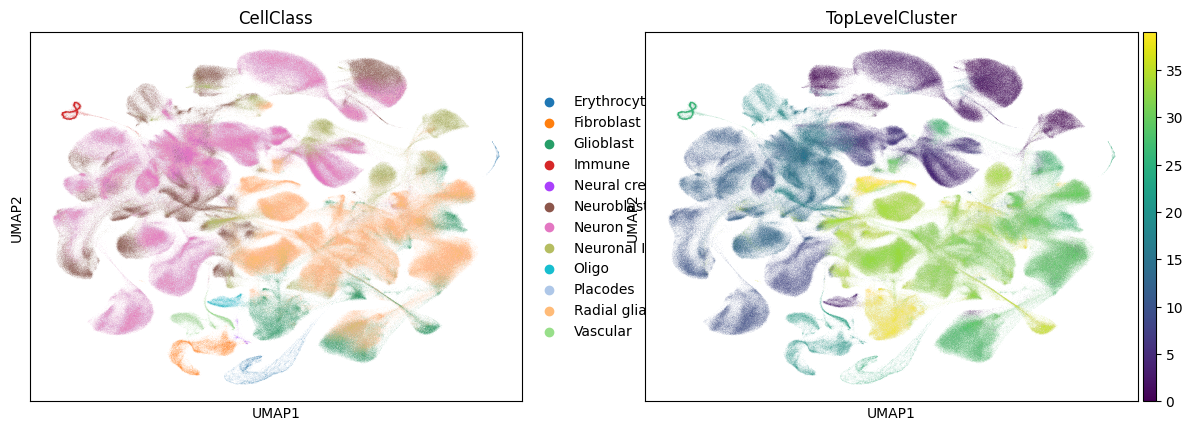

In [5]:
sc.pl.umap(braun_adata, color=['CellClass', 'TopLevelCluster'], ncols=2)

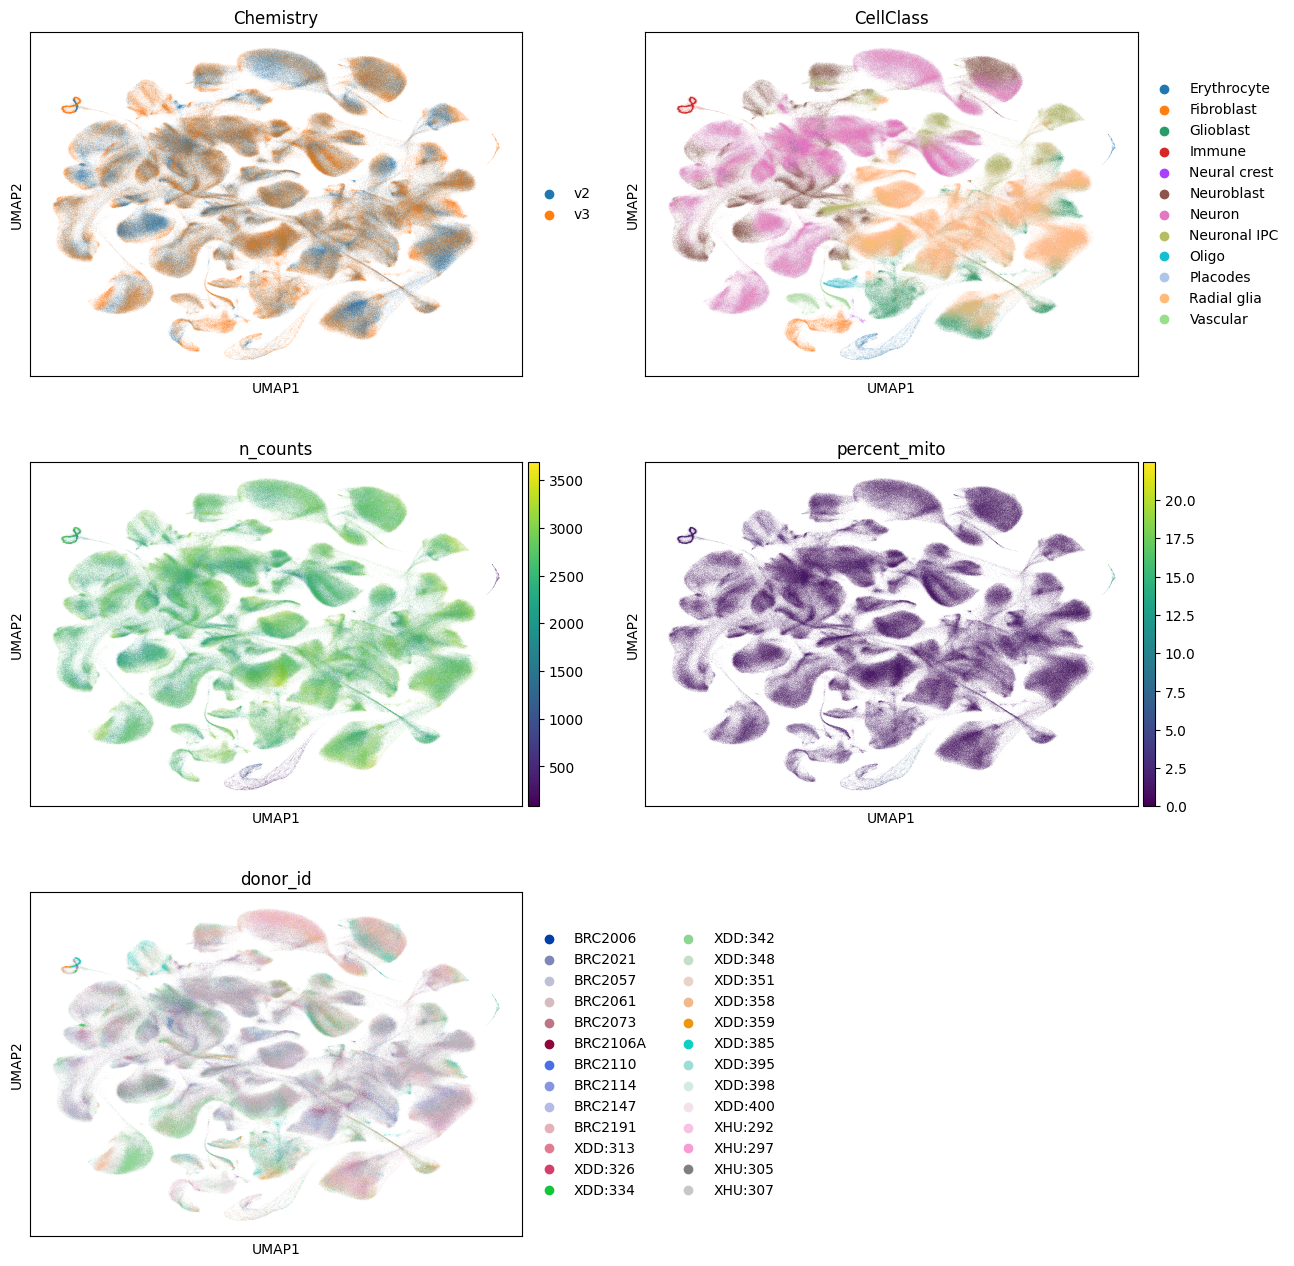

In [6]:
sc.pl.umap(braun_adata, color=['Chemistry', 'CellClass', 'n_counts', 'percent_mito', 'donor_id'], ncols=2)

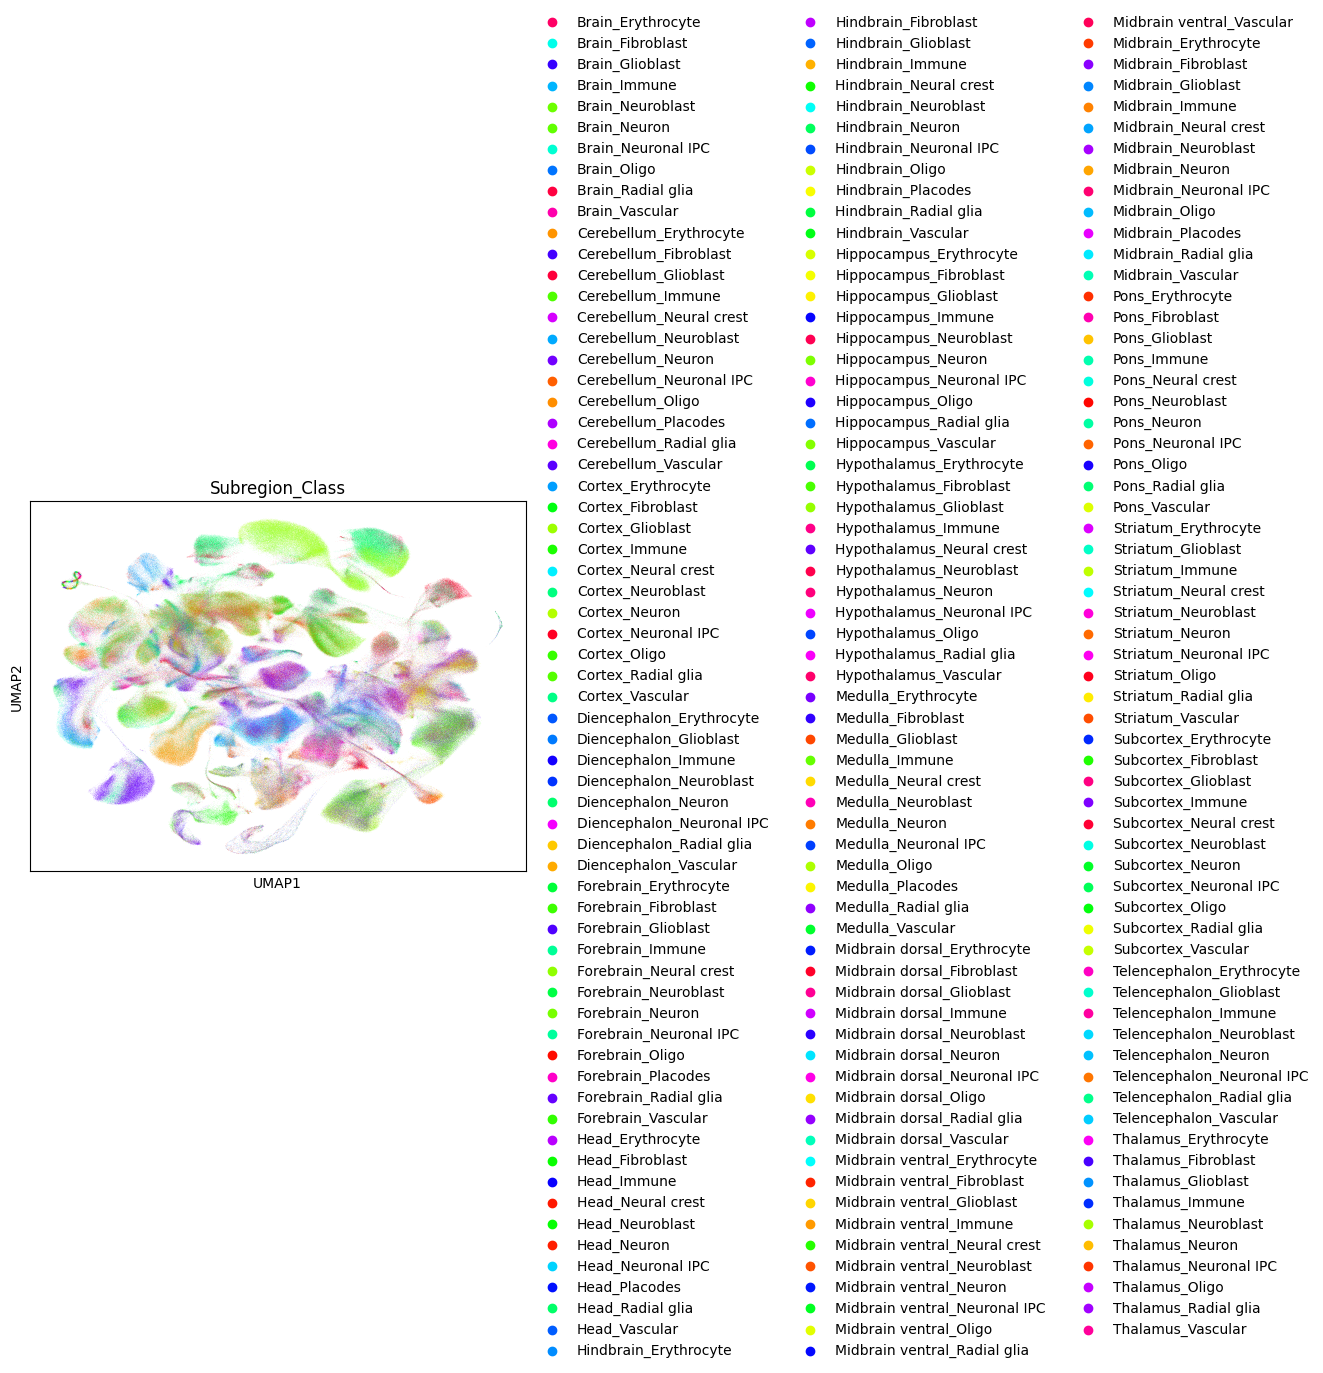

In [7]:
## Examine Subregion Class ##

cats = braun_adata.obs['Subregion_Class'].unique()
n = len(cats)

palette = sns.color_palette('hsv', n)
np.random.shuffle(palette)  # 👈 key step

# map colors to categories explicitly (important!)
color_map = dict(zip(cats, palette))

sc.pl.umap(braun_adata, color='Subregion_Class', palette=color_map)

In [8]:
## Prep Braun To Include Unseen Chemistry ##

braun_adata.obs["Chemistry"] = '10x' + braun_adata.obs["Chemistry"].astype('str')

In [9]:
## Setup Model & Begin Training ##

scvi.model.SCVI.setup_anndata(braun_adata, layer="raw_counts",     
                           #   batch_key='Chemistry',
                              categorical_covariate_keys=['donor_id', 'Chemistry'],
                              continuous_covariate_keys=["n_counts", "percent_mito"])

model = scvi.model.SCVI(braun_adata, n_hidden=1024, n_latent=30, n_layers=4)

model.train(max_epochs=30, train_size=0.9, early_stopping=True, batch_size=2048, plan_kwargs={"lr": 1e-4})

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


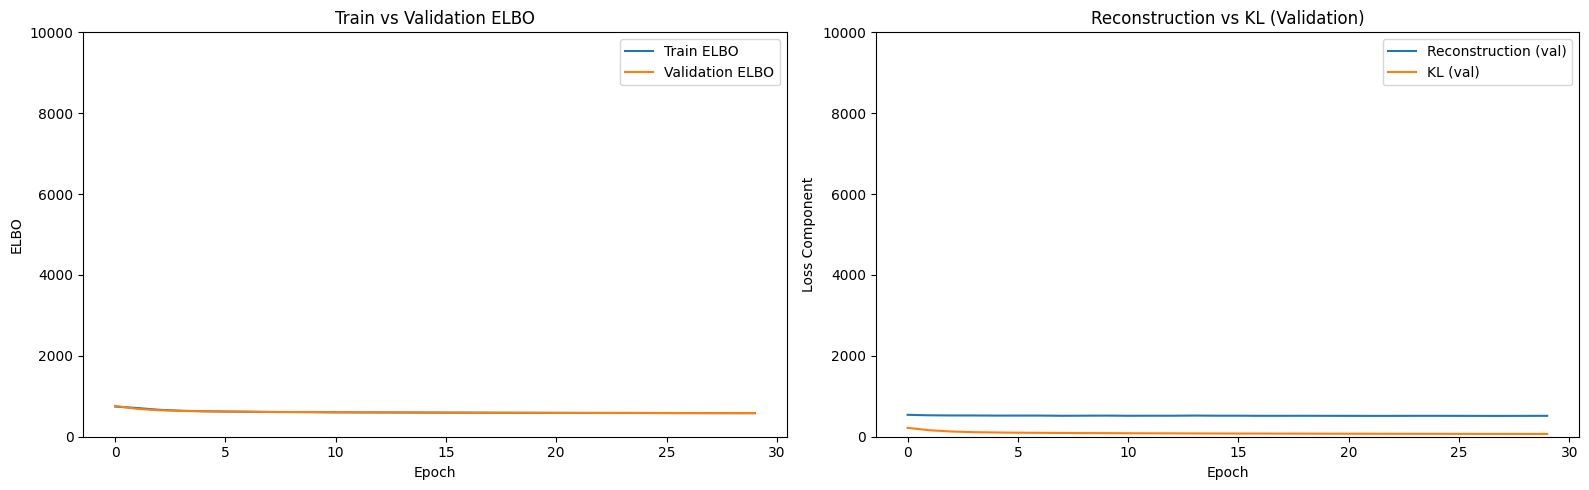

In [10]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(model.history["elbo_train"], label="Train ELBO")
axes[0].plot(model.history["elbo_validation"], label="Validation ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_ylim(0, 10000)
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(model.history["reconstruction_loss_validation"], label="Reconstruction (val)")
axes[1].plot(model.history["kl_local_validation"], label="KL (val)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_ylim(0, 10000)
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [11]:
## Save and Loading ##

model_dir = os.path.join("/mnt/sdb/scz_meta_analysis_processed/models/braun_models/", "braun_scvi")
model.save(model_dir, overwrite=True)

model = scvi.model.SCVI.load(model_dir, adata=braun_adata)

INFO     File /mnt/sdb/scz_meta_analysis_processed/models/braun_models/braun_scvi/model.pt already downloaded      


In [12]:
## Save Model Representation ##

braun_adata.obsm["X_scVI"] = model.get_latent_representation()
braun_adata.layers["scvi_normalized"] = model.get_normalized_expression(library_size=10e4, batch_size=2048)

In [13]:
## Calculate UMAP With scVI Correction ##

# use scVI latent space for UMAP generation
braun_adata = UnimodalData(braun_adata)
pg.neighbors(braun_adata, rep='scVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(braun_adata, rep='scVI', n_neighbors=15, rep_ncomps=30)
braun_adata.obsm['X_umap_scVI'] = braun_adata.obsm['X_umap']
braun_adata = braun_adata.to_anndata()

2026-04-06 00:14:15,938 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 213.99s.
2026-04-06 00:14:33,871 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 17.93s.
2026-04-06 00:14:33,872 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-06 00:14:33,872 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[      0, 354, 30, ..., 390, 1059, 8882],
       [      1, 2253, 2020, ..., 21, 8545, 6807],
       [      2, 9085, 13, ..., 8522, 8550, 9016],
       ...,
       [1665934, 1665926, 1665775, ..., 1665419, 1665566, 1662064],
       [1665935, 1664229, 1663346, ..., 1663615, 1665927, 1665925],
       [1665936, 1665933, 1661870, ..., 1663022, 1665426, 1665419]]), array([[0.       , 1.884394 , 2.0378106, ..., 2.273388 , 2.28802  ,
        2.3224454],
       [0.       , 2.627167 

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Apr  6 00:14:34 2026 Construct fuzzy simplicial set
Mon Apr  6 00:14:40 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 00:46:10 2026 Finished embedding
2026-04-06 00:46:11,180 - pegasus.tools.visualization - INFO - Function 'umap' finished in 1897.31s.


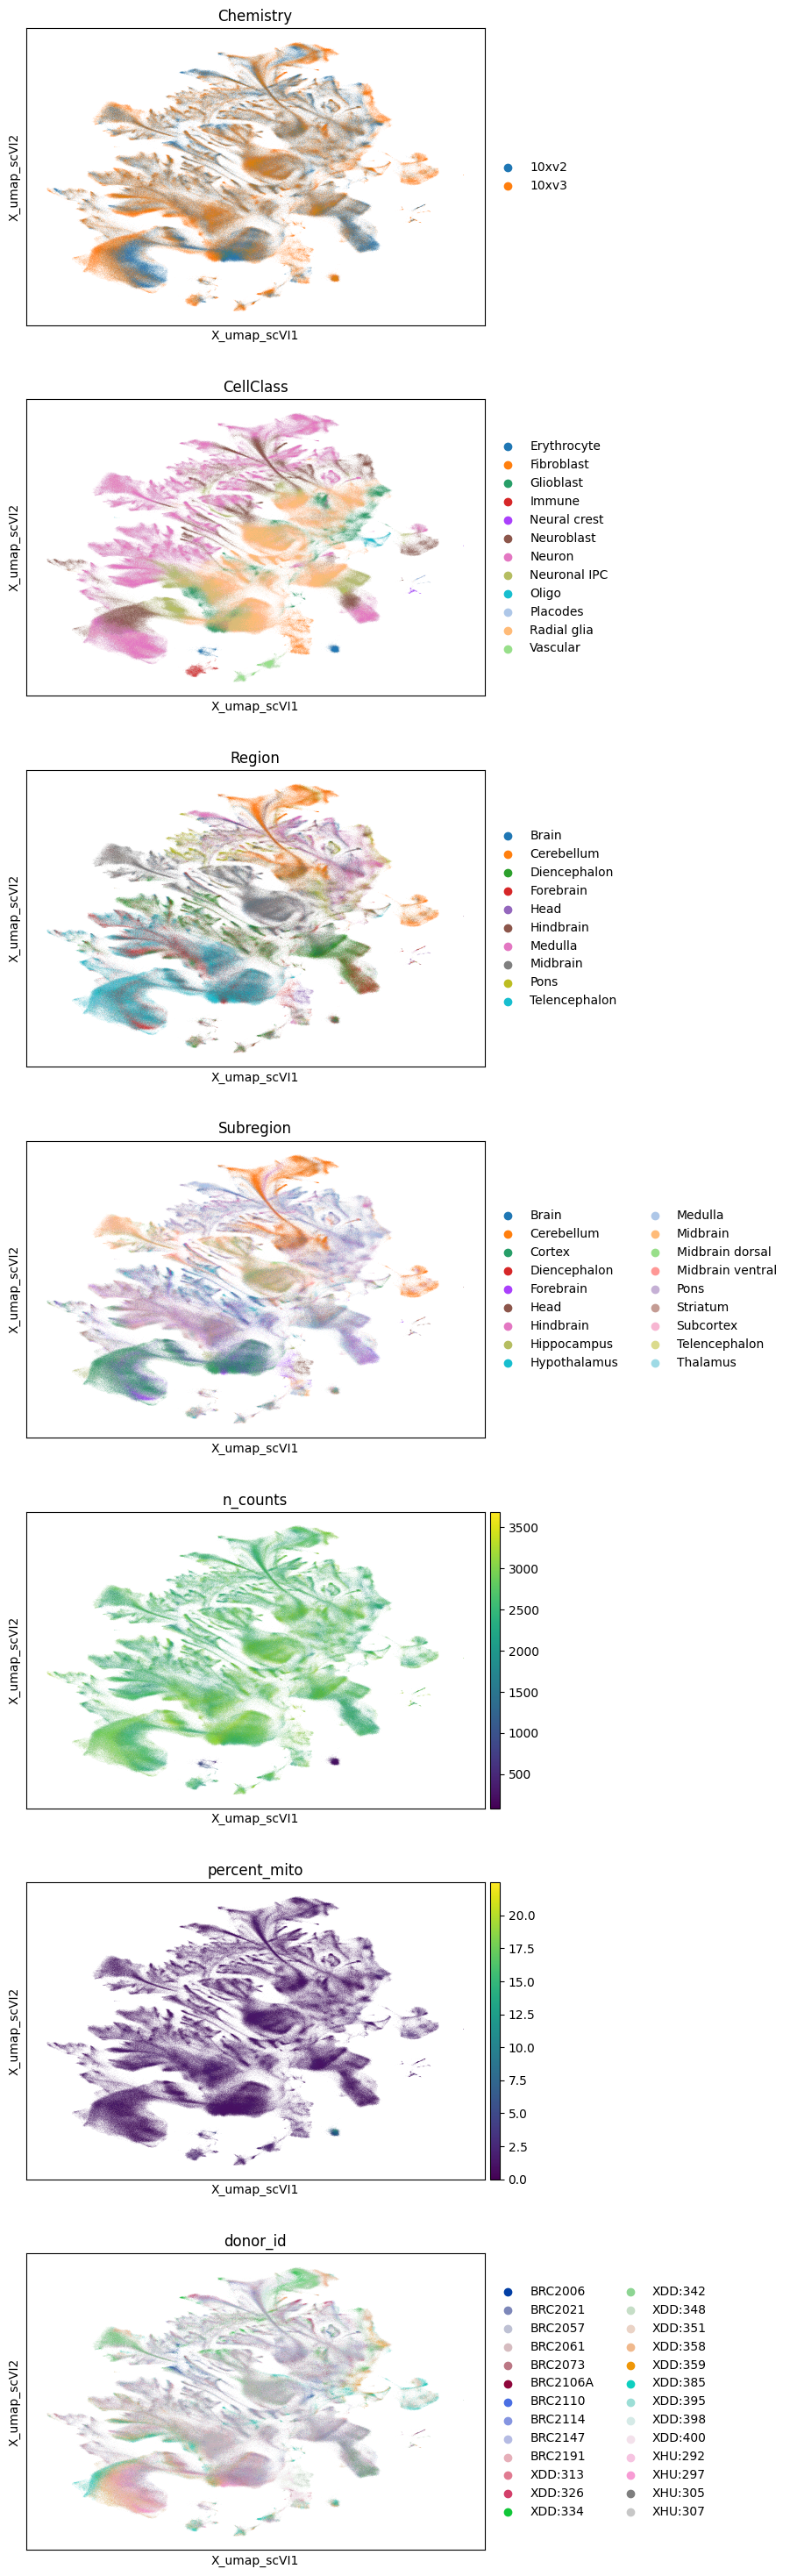

In [14]:
sc.pl.embedding(braun_adata, basis='X_umap_scVI',
                color=['Chemistry', 'CellClass', 'Region', 'Subregion', 'n_counts', 
                       'percent_mito', 'donor_id'], ncols=1)

In [15]:
## Train Supervised Part of Model ##

braun_adata.obs['CellClass'] = braun_adata.obs['CellClass'].astype(str)
braun_adata.obs['Subregion_Class'] = braun_adata.obs['Subregion_Class'].astype(str)

scanvi_model = scvi.model.SCANVI.from_scvi_model(model, adata=braun_adata,
                                                 labels_key="Subregion_Class",
                                                 unlabeled_category="Unknown")

scanvi_model.train(max_epochs=15, batch_size=2048, plan_kwargs={"lr": 1e-4}) # gradient_clip_val=10.0)

scanvi_model.save("/mnt/sdb/scz_meta_analysis_processed/models/braun_adata_models/braun_adata_scvi/", overwrite=True)

INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:186: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  categorical_mapping = _make_column_categorical(
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_scanvi.py:55: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(


INFO     Training for 15 epochs.                                                                                   


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/15 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


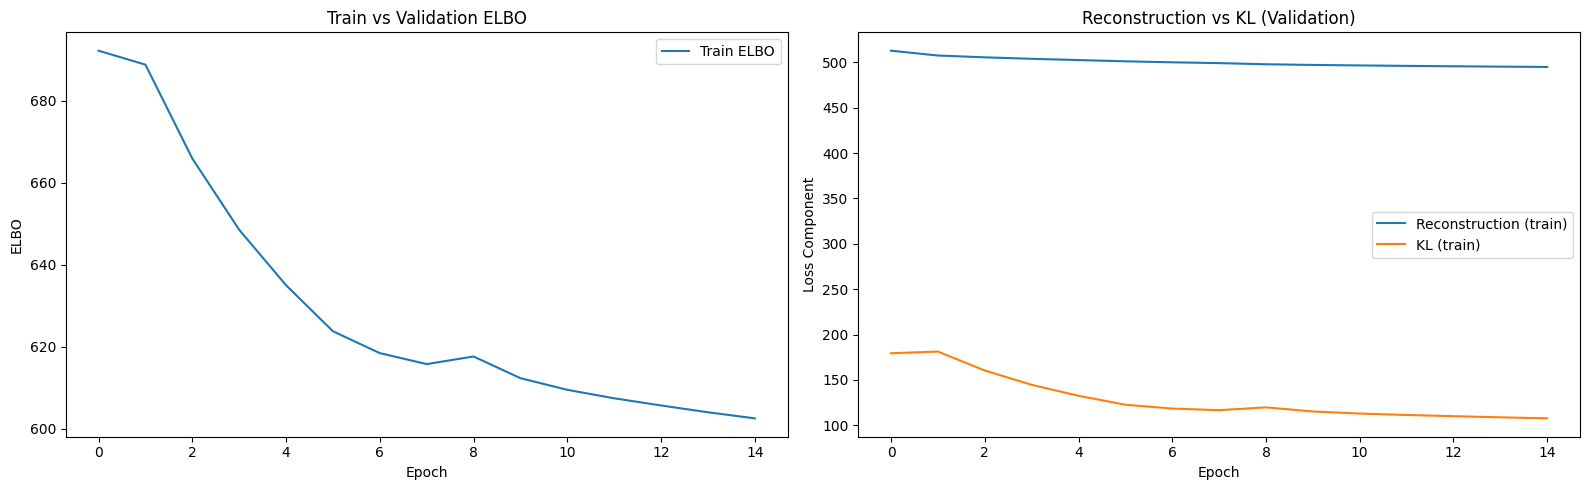

In [16]:
## Examine Train/Val Loss ELBO and Reconstruction/Kullback-Leiber Val Loss

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ---- Left plot: Train vs Validation ELBO ----
axes[0].plot(scanvi_model.history["elbo_train"], label="Train ELBO")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("ELBO")
axes[0].set_title("Train vs Validation ELBO")
axes[0].legend()

# ---- Right plot: Reconstruction vs KL ----
axes[1].plot(scanvi_model.history["reconstruction_loss_train"], label="Reconstruction (train)")
axes[1].plot(scanvi_model.history["kl_local_train"], label="KL (train)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss Component")
axes[1].set_title("Reconstruction vs KL (Validation)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [17]:
braun_adata.obsm

AxisArrays with keys: Factors, X_Embedding, X_pca, X_pca_regressed, X_pca_regressed_harmony, X_umap, pca_regressed_harmony_knn_distances, pca_regressed_harmony_knn_indices, pca_regressed_knn_distances, pca_regressed_knn_indices, sig_bkg_mean, sig_bkg_std, _scvi_extra_categorical_covs, _scvi_extra_continuous_covs, X_scVI, scVI_knn_indices, scVI_knn_distances, X_umap_scVI

In [18]:
braun_adata.obs[['donor_id']].value_counts().shape

(26,)

In [19]:
braun_adata.obs[['sample_id']].value_counts().shape

(340,)

In [20]:
braun_adata.obs.columns

Index(['Age', 'CellClass', 'Chemistry', 'Region', 'Subregion',
       'organism_ontology_term_id', 'disease_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'assay_ontology_term_id',
       'sex_ontology_term_id', 'development_stage_ontology_term_id',
       'donor_id', 'suspension_type', 'tissue_type', 'dissection',
       'tissue_ontology_term_id', 'cell_type_ontology_term_id',
       'fraction_mitochondrial', 'fraction_unspliced', 'cell_cycle_score',
       'total_genes', 'total_UMIs', 'sample_id', 'cluster_id', 'Tissue',
       'Subdivision', 'DoubletFlag', 'TotalUMIs', 'DoubletScore',
       'TopLevelCluster', 'CellCycleFraction', 'n_genes', 'n_counts',
       'percent_mito', 'passed_qc', 'G1/S', 'G2/M', 'cycle_diff', 'cycling',
       'predicted_phase', 'total_counts', 'class', 'Subregion_Class',
       '_scvi_batch', '_scvi_labels'],
      dtype='object')

In [21]:
## Calculate UMAP With scVI Correction ##

braun_adata.obsm["X_scANVI"] = scanvi_model.get_latent_representation(braun_adata)

# use scVI latent space for UMAP generation
braun_adata = UnimodalData(braun_adata)
pg.neighbors(braun_adata, rep='scANVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(braun_adata, rep='scANVI', n_neighbors=15, rep_ncomps=30)
braun_adata.obsm['X_umap_scANVI'] = braun_adata.obsm['X_umap']
braun_adata = braun_adata.to_anndata()

2026-04-06 04:38:10,731 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 156.84s.
2026-04-06 04:38:29,271 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 18.54s.
2026-04-06 04:38:29,272 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-06 04:38:29,273 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.
UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[      0, 180, 7438, ..., 7168, 6896, 6954],
       [      1, 21, 8336, ..., 27, 902, 3859],
       [      2, 13, 1372, ..., 7980, 6609, 4847],
       ...,
       [1665934, 1665936, 1665926, ..., 1665775, 1665382, 1665787],
       [1665935, 1665929, 1665925, ..., 1664221, 1663120, 1665793],
       [1665936, 1665933, 1665916, ..., 1661893, 1665782, 1665923]]), array([[0.       , 1.2439907, 1.2679757, ..., 1.507891 , 1.5099895,
        1.5135591],
       [0.       , 1.3012459

/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Mon Apr  6 04:38:29 2026 Construct fuzzy simplicial set
Mon Apr  6 04:38:34 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 05:09:39 2026 Finished embedding
2026-04-06 05:09:39,824 - pegasus.tools.visualization - INFO - Function 'umap' finished in 1870.55s.


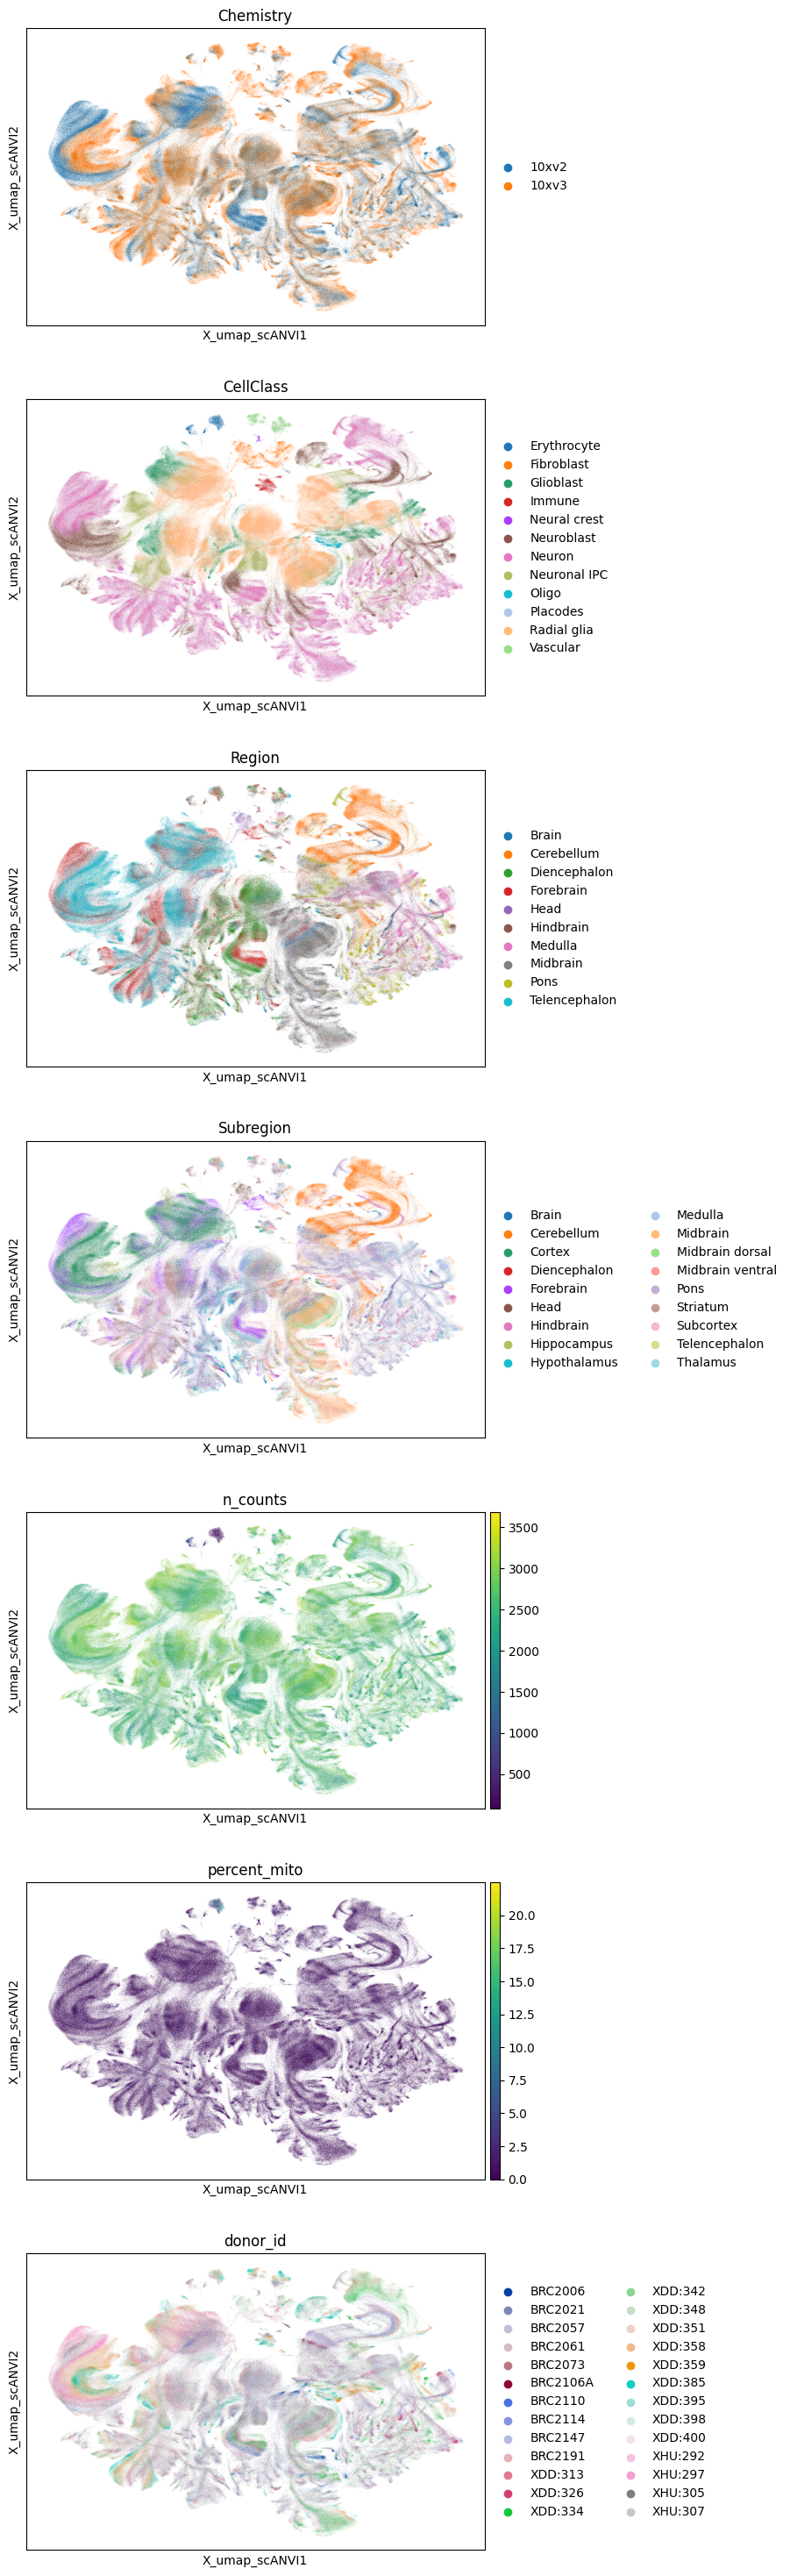

In [22]:
sc.pl.embedding(braun_adata, basis='X_umap_scANVI', 
                color=['Chemistry', 'CellClass', 'Region', 'Subregion', 'n_counts', 
                        'percent_mito', 'donor_id'], ncols=1)

In [23]:
## Prep Query for Mapping ##

# make query donor category like reference
adata.obs['donor_id'] = adata.obs['Donor']

adata.obs['CellClass'] = 'Unknown'
adata.obs['Subregion_Class'] = 'Unknown'

query_ref = sc.concat([adata, braun_adata], axis=0, label='origin', keys=['kaji', 'braun_adata'], join='outer')

In [24]:
adata = query_ref[query_ref.obs['origin'] == 'kaji'].copy()
gc.collect()

38535

In [25]:
## Update With Query ##

scvi.model.SCANVI.prepare_query_anndata(adata, scanvi_model)

scanvi_model_q = scvi.model.SCANVI.load_query_data(adata, scanvi_model)
scanvi_model_q.train(max_epochs=30, plan_kwargs={"weight_decay": 0.0, "lr": 1e-4}) 
scanvi_model_q.save("/mnt/sdb/scz_meta_analysis_processed/models/braun_adata_models/braun_adata_scvi/", overwrite=True)

INFO     Found 100.0% reference vars in query data.                                                                
INFO     Training for 30 epochs.                                                                                   


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/model/_scanvi.py:139: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(self.adata_manager, n_batch)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Training:   0%|          | 0/30 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=30` reached.


In [26]:
## Predict ##

query_ref.obs["Pred_Celltype"] = scanvi_model_q.predict(query_ref)

INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_dataframe_field.py:224: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  new_mapping = _make_column_categorical(
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/scvi/data/fields/_scanvi.py:55: UserWarning: Category 1 in adata.obs['_scvi_labels'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(


In [27]:
## Get Latent Representation ##

query_ref.obsm["X_scANVI"] = scanvi_model_q.get_latent_representation(query_ref)

query_ref = UnimodalData(query_ref)
pg.neighbors(query_ref, rep='scANVI', use_cache=False, dist='l2', K=50, n_comps=30)
pg.umap(query_ref, rep='scANVI', n_neighbors=15, rep_ncomps=30)
query_ref.obsm['X_umap_scANVI'] = query_ref.obsm['X_umap']

2026-04-06 10:28:54,570 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 390.87s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/nearest_neighbors.py:257: RuntimeWarning: invalid value encountered in divide
  normed_dist[i, :] = np.sqrt(numers / denoms) * np.exp(
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/nearest_neighbors.py:258: RuntimeWarning: divide by zero encountered in divide
  -np.square(distances[i, :]) / denoms
/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/pegasus/tools/nearest_neighbors.py:258: RuntimeWarning: invalid value encountered in divide
  -np.square(distances[i, :]) / denoms


2026-04-06 10:29:30,711 - pegasus.tools.nearest_neighbors - INFO - Function 'calculate_affinity_matrix' finished in 36.14s.
2026-04-06 10:29:30,711 - pegasus.tools.nearest_neighbors - INFO - Found cached kNN results, no calculation is required.
2026-04-06 10:29:30,712 - pegasus.tools.nearest_neighbors - INFO - Function 'get_neighbors' finished in 0.00s.


/home/deepak/pixi_envs/scanvi/.pixi/envs/default/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP(min_dist=0.5, n_jobs=1, precomputed_knn=(array([[      0, 301460, 117672, ..., 42, 242081, 170792],
       [      1, 104, 75929, ..., 107516, 171788, 171684],
       [      2, 324696, 177602, ..., 308250, 135251, 75914],
       ...,
       [3240099, 3240101, 3240091, ..., 3239940, 3239547, 3239952],
       [3240100, 3240094, 3240090, ..., 3238386, 3237285, 3239958],
       [3240101, 3240098, 3240081, ..., 3236058, 3239947, 3240088]]), array([[0.       , 2.5354207, 2.760677 , ..., 3.2894852, 3.3272512,
        3.327652 ],
       [0.       , 2.2019374, 2.302843 , ..., 2.5463464, 2.5475917,
        2.5763588],
       [0.       , 2.7615259, 2.8297498, ..., 3.3103502, 3.3433385,
        3.3449357],
       ...,
       [0.       , 3.6496305, 3.7906775, ..., 4.4938607, 4.510658 ,
        4.5253716],
       [0.       , 4.0382547, 4.130876 , ..., 5.067939 , 5.0851636,
        5.122597 ],
       [0.       , 3.0960276, 3.3579452, ..., 4.5138874, 4.5441036,
        4.615333 ]], dtype=float32),

Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Mon Apr  6 10:50:12 2026 Finished embedding
2026-04-06 10:50:12,787 - pegasus.tools.visualization - INFO - Function 'umap' finished in 1242.08s.


In [28]:
query_ref = query_ref.to_anndata()

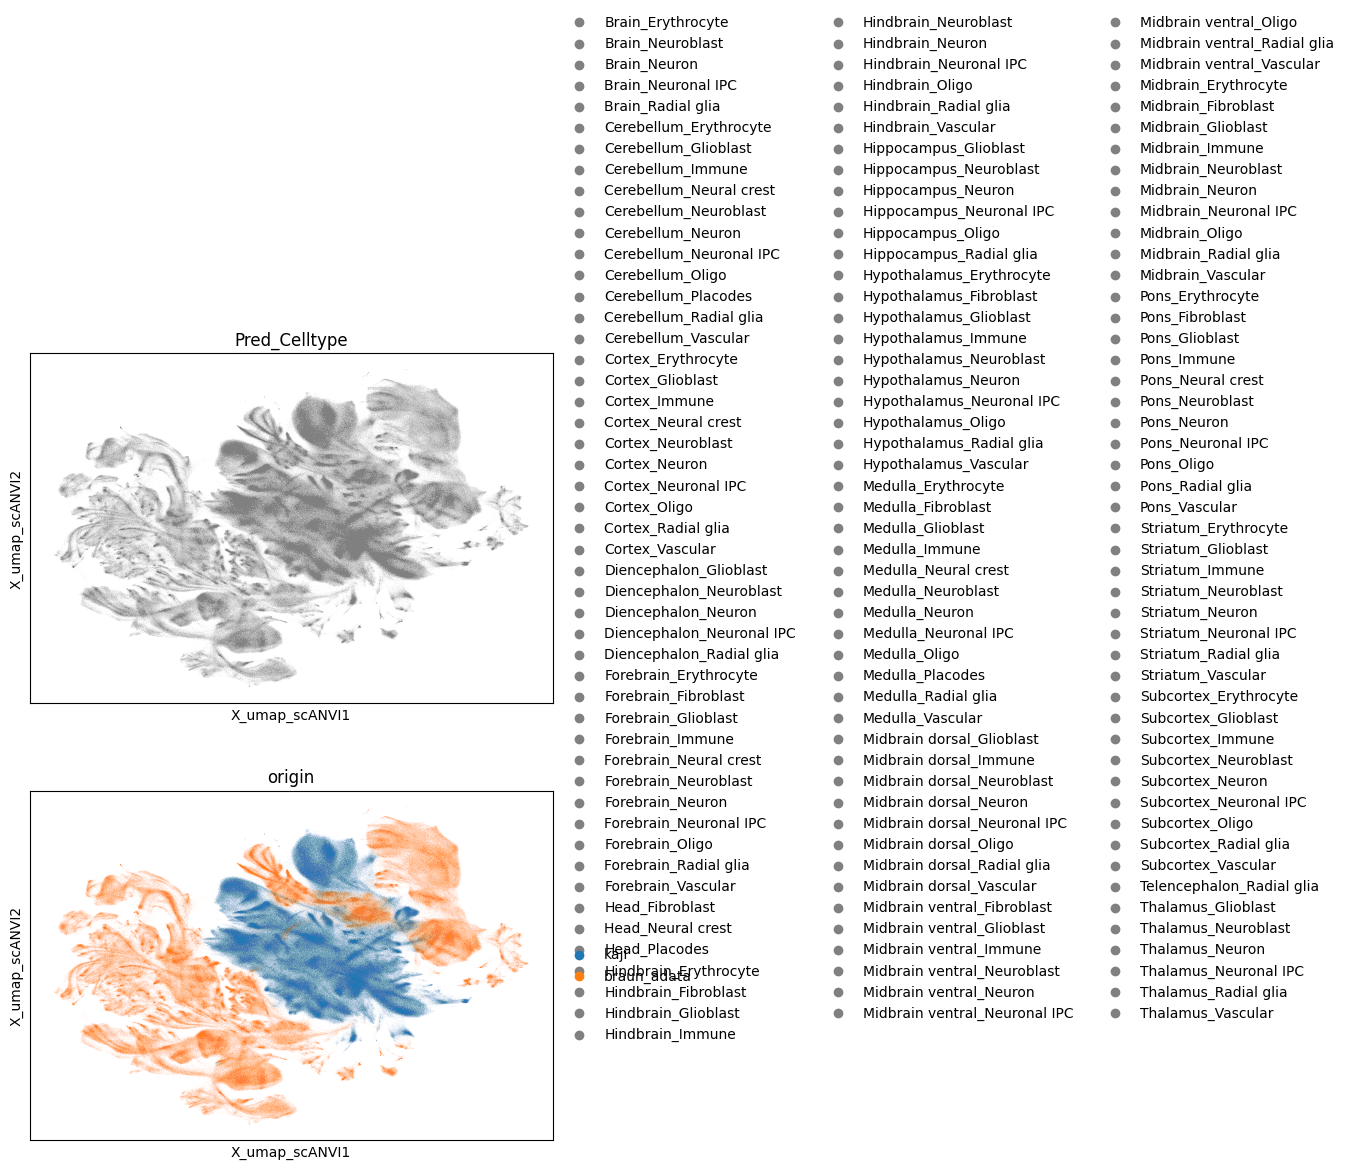

In [29]:
sc.pl.embedding(query_ref, basis='X_umap_scANVI', color=['Pred_Celltype', 'origin'], ncols=1)

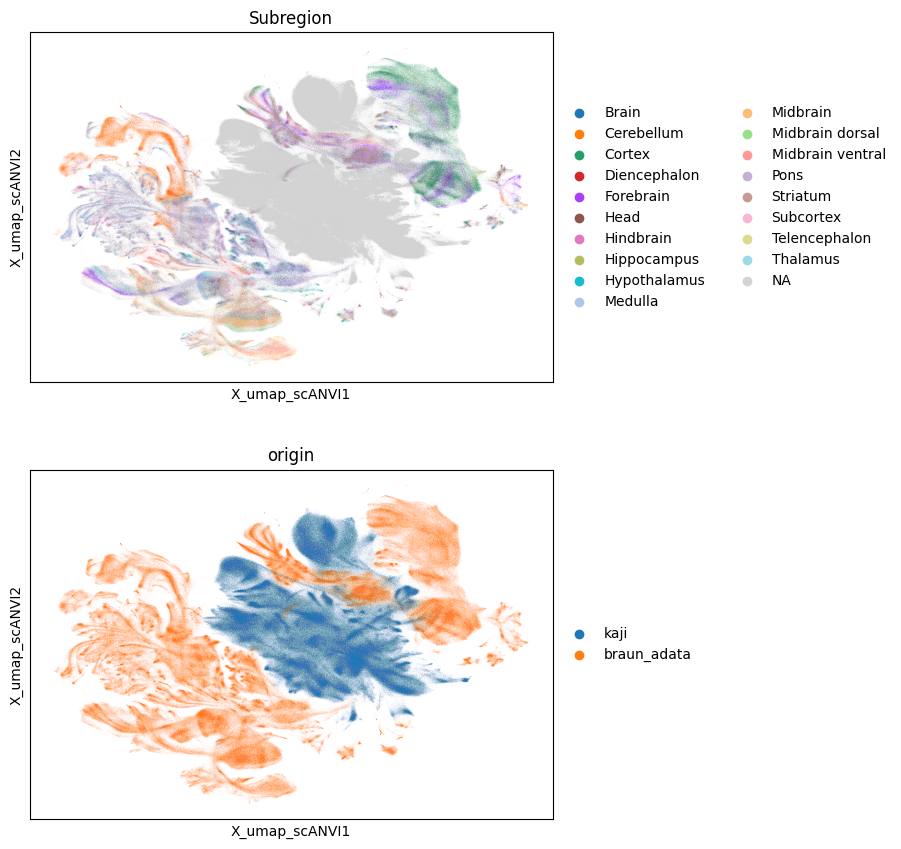

In [30]:
sc.pl.embedding(query_ref, basis='X_umap_scANVI', color=['Subregion', 'origin'], ncols=1)

In [31]:
## Save ##

query_ref.obs['Age'] = query_ref.obs['Age'].astype('str')

query_ref.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/scz_adata_braun_scanvi_integrated.h5ad')

In [32]:
## Adata add ["X_scANVI","Pred_Celltype"] ##

adata.obsm["X_scANVI"] = scanvi_model_q.get_latent_representation(adata)

adata.obs["Pred_Celltype"] = scanvi_model_q.predict(adata)

adata.write_h5ad('/mnt/sdb/scz_meta_analysis_processed/anndata_objs/adata_only_with_braun_scanvi.h5ad')

In [33]:
# latent representation
np.save("/mnt/sdb/scz_meta_analysis_processed/anndata_objs/adata_in_braun_X_scANVI.npy", adata.obsm["X_scANVI"])

# predicted labels
adata.obs[["Pred_Celltype"]].to_csv("/mnt/sdb/scz_meta_analysis_processed/anndata_objs/adata_pred_celltype_from_braun.csv")

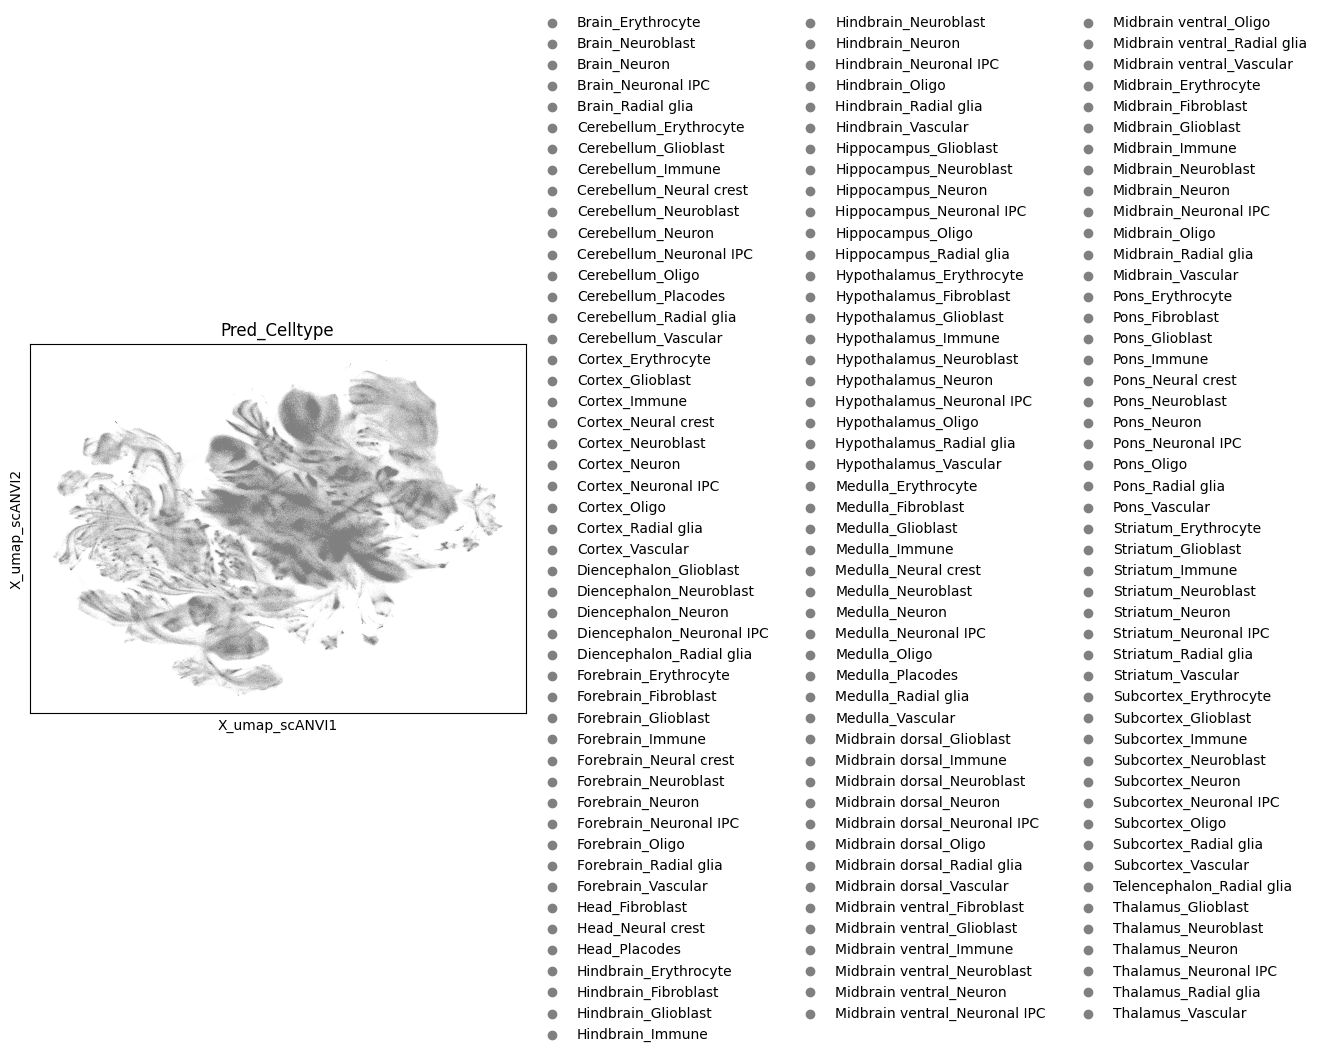

In [36]:
sc.pl.embedding(query_ref, basis='X_umap_scANVI', color='Pred_Celltype')